# Energy Consumption and Sustainability Analysis





### Mount Google Drive dan Setup Path

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style='whitegrid')

## Load Dataset
PROJECT_PATH = '/content/drive/MyDrive/Portfolio/energy-consumption-analysis'
RAW_PATH = f'{PROJECT_PATH}/data/raw'
PROCESSED_PATH = f'{PROJECT_PATH}/data/processed'
IMAGE_PATH = f'{PROJECT_PATH}/images'

os.makedirs(PROCESSED_PATH, exist_ok=True)
os.makedirs(IMAGE_PATH, exist_ok=True)

print('Project path:', PROJECT_PATH)

Mounted at /content/drive
Project path: /content/drive/MyDrive/Portfolio/energy-consumption-analysis


### Load and Cleaning

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = f'{RAW_PATH}/household_power_consumption.txt'
energy = pd.read_csv(
    file_path,
    sep=';',
    na_values=['?'],
    low_memory=False
)

print('Shape:', energy.shape)
print(energy.head())
print(energy.dtypes)
print(energy.isna().sum())

energy['Datetime'] = pd.to_datetime(
    energy['Date'].astype(str) + ' ' + energy['Time'].astype(str),
    format='%d/%m/%Y %H:%M:%S',
    errors='coerce'
)

energy = energy.drop(columns=['Date', 'Time'])

numeric_cols = [c for c in energy.columns if c != 'Datetime']
for col in numeric_cols:
    energy[col] = pd.to_numeric(energy[col], errors='coerce')

energy = (
    energy.dropna(subset=['Datetime', 'Global_active_power'])
    .sort_values('Datetime')
    .reset_index(drop=True)
)

energy['Hour'] = energy['Datetime'].dt.hour
energy['DayOfWeek'] = energy['Datetime'].dt.day_name()
energy['DayOfWeekNum'] = energy['Datetime'].dt.dayofweek
energy['IsWeekend'] = energy['DayOfWeekNum'] >= 5
energy['Month'] = energy['Datetime'].dt.to_period('M').astype(str)

# Global_active_power is kW averaged over one minute.
# Therefore kWh for each one-minute interval = kW / 60.
energy['Interval_kWh'] = energy['Global_active_power'] / 60

energy.to_csv(f'{PROCESSED_PATH}/energy_clean.csv', index=False)
print('Clean rows:', len(energy))

Shape: (2075259, 9)
         Date      Time  Global_active_power  Global_reactive_power  Voltage  \
0  16/12/2006  17:24:00                4.216                  0.418   234.84   
1  16/12/2006  17:25:00                5.360                  0.436   233.63   
2  16/12/2006  17:26:00                5.374                  0.498   233.29   
3  16/12/2006  17:27:00                5.388                  0.502   233.74   
4  16/12/2006  17:28:00                3.666                  0.528   235.68   

   Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  
0              18.4             0.0             1.0            17.0  
1              23.0             0.0             1.0            16.0  
2              23.0             0.0             2.0            17.0  
3              23.0             0.0             1.0            17.0  
4              15.8             0.0             1.0            17.0  
Date                      object
Time                      object
Global_active

### Agregasi Inti

In [3]:
# --- Cell 5: Agregasi Inti ---

hourly_profile = (
    energy.groupby('Hour')['Global_active_power']
    .agg(avg_power_kw='mean', peak_power_kw='max')
    .reset_index()
)

weekday_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

day_profile = (
    energy.groupby(
        ['DayOfWeekNum', 'DayOfWeek', 'IsWeekend']
    )['Global_active_power']
    .mean()
    .reset_index(name='avg_power_kw')
    .sort_values('DayOfWeekNum')
)

monthly = (
    energy.groupby('Month')['Interval_kWh']
    .sum()
    .reset_index(name='total_kwh')
)

submeter = energy[[
    'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3'
]].mean()

submeter_df = submeter.reset_index()
submeter_df.columns = ['sub_metering', 'avg_kwh_per_min']

peak_hour = hourly_profile.loc[
    hourly_profile['avg_power_kw'].idxmax()
]
print('Peak hour:', peak_hour.to_dict())
print(monthly.head())
print(submeter)

# Save aggregation results
os.makedirs(PROCESSED_PATH, exist_ok=True)

hourly_profile.to_csv(
    f'{PROCESSED_PATH}/hourly_profile.csv',
    index=False
)

day_profile.to_csv(
    f'{PROCESSED_PATH}/day_profile.csv',
    index=False
)

monthly.to_csv(
    f'{PROCESSED_PATH}/monthly_energy.csv',
    index=False
)

submeter_df.to_csv(
    f'{PROCESSED_PATH}/submeter_avg.csv',
    index=False
)

print('Aggregation results saved.')

Peak hour: {'Hour': 20.0, 'avg_power_kw': 1.899064135957484, 'peak_power_kw': 10.348}
     Month    total_kwh
0  2006-12   696.888033
1  2007-01  1150.197700
2  2007-02   941.481433
3  2007-03   981.036533
4  2007-04   586.357767
Sub_metering_1    1.121923
Sub_metering_2    1.298520
Sub_metering_3    6.458447
dtype: float64
Aggregation results saved.


### Estimasi Biaya dan Load Shifting

In [4]:
# --- Cell 6: Estimasi Biaya dan Load Shifting ---

tariff_per_kwh = 0.20
monthly['estimated_cost'] = (
    monthly['total_kwh'] * tariff_per_kwh
)

peak_threshold = hourly_profile[
    'avg_power_kw'
].quantile(0.90)

peak_hours = hourly_profile.loc[
    hourly_profile['avg_power_kw'] >= peak_threshold,
    'Hour'
].tolist()

peak_energy = energy[
    energy['Hour'].isin(peak_hours)
]['Interval_kWh'].sum()

shiftable_energy = peak_energy * 0.20
estimated_saving = (
    shiftable_energy * tariff_per_kwh * 0.10
)

print('Peak hours:', peak_hours)
print(f'Peak energy (estimated): {peak_energy:,.2f} kWh')
print(f'Estimated shiftable: {shiftable_energy:,.2f} kWh')
print(f'Estimated saving: {estimated_saving:,.2f}')

# Save summary
summary_rows = [
    {'metric': 'tariff_per_kwh', 'value': tariff_per_kwh},
    {'metric': 'peak_hours', 'value': str(peak_hours)},
    {'metric': 'peak_energy_kwh', 'value': round(peak_energy, 2)},
    {'metric': 'shiftable_energy_kwh', 'value': round(shiftable_energy, 2)},
    {'metric': 'estimated_saving', 'value': round(estimated_saving, 2)},
]

cost_summary = pd.DataFrame(summary_rows)
cost_summary.to_csv(
    f'{PROCESSED_PATH}/cost_and_load_shifting_summary.csv',
    index=False
)

monthly.to_csv(
    f'{PROCESSED_PATH}/monthly_energy_with_cost.csv',
    index=False
)

print('Cost summary saved.')

Peak hours: [19, 20, 21]
Peak energy (estimated): 7,857.65 kWh
Estimated shiftable: 1,571.53 kWh
Estimated saving: 31.43
Cost summary saved.


### Visualisasi

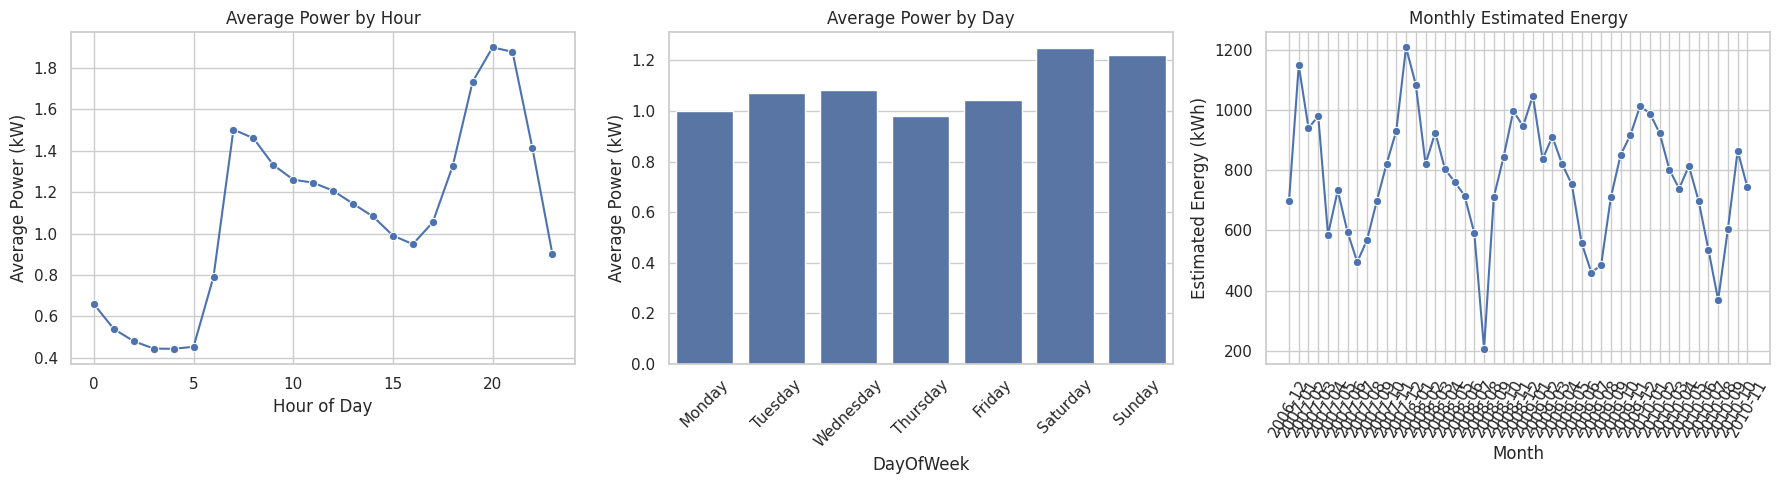

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.lineplot(data=hourly_profile, x='Hour', y='avg_power_kw', marker='o', ax=axes[0])
axes[0].set_title('Average Power by Hour')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Average Power (kW)')

sns.barplot(data=day_profile, x='DayOfWeek', y='avg_power_kw', ax=axes[1], order=weekday_order)
axes[1].set_title('Average Power by Day')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('Average Power (kW)')

sns.lineplot(data=monthly, x='Month', y='total_kwh', marker='o', ax=axes[2])
axes[2].set_title('Monthly Estimated Energy')
axes[2].tick_params(axis='x', rotation=60)
axes[2].set_ylabel('Estimated Energy (kWh)')

plt.tight_layout()
plt.savefig(f'{IMAGE_PATH}/energy_profiles.png', dpi=160, bbox_inches='tight')
plt.show()

### SQL Queries

In [6]:
!pip -q install duckdb
import duckdb

con = duckdb.connect()
con.register('energy', energy)

# Query 1: Hourly profile
sql_hourly = con.sql('''
    SELECT Hour,
           ROUND(AVG(Global_active_power), 3) AS avg_power_kw,
           ROUND(MAX(Global_active_power), 3) AS max_power_kw,
           ROUND(SUM(Interval_kWh), 2) AS estimated_kwh
    FROM energy
    GROUP BY Hour
    ORDER BY Hour
''').df()
print('=== Hourly Power Profile (SQL) ===')
print(sql_hourly)

# Query 2: Monthly energy trend
sql_monthly = con.sql('''
    SELECT Month,
           COUNT(*) AS interval_count,
           ROUND(SUM(Interval_kWh), 2) AS total_kwh,
           ROUND(AVG(Global_active_power), 3) AS avg_power_kw,
           ROUND(MAX(Global_active_power), 3) AS max_power_kw
    FROM energy
    GROUP BY Month
    ORDER BY Month
''').df()
print('\n=== Monthly Energy Trend (SQL) ===')
print(sql_monthly)

# Query 3: Weekday vs Weekend comparison
sql_weekday_weekend = con.sql('''
    SELECT
        CASE WHEN IsWeekend THEN 'Weekend' ELSE 'Weekday' END
            AS day_type,
        COUNT(*) AS interval_count,
        ROUND(AVG(Global_active_power), 3) AS avg_power_kw,
        ROUND(MAX(Global_active_power), 3) AS max_power_kw,
        ROUND(SUM(Interval_kWh), 2) AS total_kwh,
        ROUND(
            SUM(Interval_kWh) / COUNT(DISTINCT CAST(Datetime AS DATE)),
            2
        ) AS avg_daily_kwh
    FROM energy
    GROUP BY
        CASE WHEN IsWeekend THEN 'Weekend' ELSE 'Weekday' END
    ORDER BY day_type
''').df()
print('\n=== Weekday vs Weekend (SQL) ===')
print(sql_weekday_weekend)

# Query 4: Top sub-metering hours
sql_submeter_hourly = con.sql('''
    SELECT Hour,
           ROUND(AVG(Sub_metering_1), 3) AS avg_sub1_kitchen,
           ROUND(AVG(Sub_metering_2), 3) AS avg_sub2_laundry,
           ROUND(AVG(Sub_metering_3), 3) AS avg_sub3_hvac,
           ROUND(
               AVG(Sub_metering_1)
               + AVG(Sub_metering_2)
               + AVG(Sub_metering_3),
               3
           ) AS avg_total_sub_metered
    FROM energy
    GROUP BY Hour
    ORDER BY avg_total_sub_metered DESC
''').df()
print('\n=== Top Sub-Metering Hours (SQL) ===')
print(sql_submeter_hourly)

# Query 5: Daily profile
sql_daily = con.sql('''
    SELECT DayOfWeek,
           DayOfWeekNum,
           ROUND(AVG(Global_active_power), 3) AS avg_power_kw,
           ROUND(SUM(Interval_kWh), 2) AS total_kwh,
           COUNT(DISTINCT CAST(Datetime AS DATE)) AS day_count
    FROM energy
    GROUP BY DayOfWeek, DayOfWeekNum
    ORDER BY DayOfWeekNum
''').df()
print('\n=== Daily Power Profile (SQL) ===')
print(sql_daily)

# Save all SQL results
os.makedirs(PROCESSED_PATH, exist_ok=True)

sql_hourly.to_csv(
    f'{PROCESSED_PATH}/sql_hourly_profile.csv',
    index=False
)
sql_monthly.to_csv(
    f'{PROCESSED_PATH}/sql_monthly_trend.csv',
    index=False
)
sql_weekday_weekend.to_csv(
    f'{PROCESSED_PATH}/sql_weekday_weekend.csv',
    index=False
)
sql_submeter_hourly.to_csv(
    f'{PROCESSED_PATH}/sql_submeter_hourly.csv',
    index=False
)
sql_daily.to_csv(
    f'{PROCESSED_PATH}/sql_daily_profile.csv',
    index=False
)
print('\nAll SQL query results saved to:', PROCESSED_PATH)

=== Hourly Power Profile (SQL) ===
    Hour  avg_power_kw  max_power_kw  estimated_kwh
0      0         0.659         7.698         939.59
1      1         0.539        10.290         768.00
2      2         0.481         6.248         684.40
3      3         0.445         4.426         633.40
4      4         0.444         4.796         631.13
5      5         0.454         6.376         644.67
6      6         0.792         8.310        1124.85
7      7         1.502         9.486        2135.29
8      8         1.461         8.126        2076.96
9      9         1.332         7.732        1893.51
10    10         1.261         9.078        1791.10
11    11         1.246         8.504        1770.06
12    12         1.207         9.224        1716.40
13    13         1.145         9.590        1627.91
14    14         1.083         8.418        1541.33
15    15         0.991         8.848        1409.82
16    16         0.949         8.446        1349.58
17    17         1.055       

In [7]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os

# Download semua file project
!zip -r /content/energy_consumption_export.zip \
    /content/drive/MyDrive/Portfolio/energy-consumption-analysis/

from google.colab import files
files.download('/content/energy_consumption_export.zip')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  adding: content/drive/MyDrive/Portfolio/energy-consumption-analysis/ (stored 0%)
  adding: content/drive/MyDrive/Portfolio/energy-consumption-analysis/images/ (stored 0%)
  adding: content/drive/MyDrive/Portfolio/energy-consumption-analysis/images/energy_profiles.png (deflated 11%)
  adding: content/drive/MyDrive/Portfolio/energy-consumption-analysis/notebooks/ (stored 0%)
  adding: content/drive/MyDrive/Portfolio/energy-consumption-analysis/notebooks/energy_consumption_analysis.ipynb (deflated 73%)
  adding: content/drive/MyDrive/Portfolio/energy-consumption-analysis/data/ (stored 0%)
  adding: content/drive/MyDrive/Portfolio/energy-consumption-analysis/data/raw/ (stored 0%)
  adding: content/drive/MyDrive/Portfolio/energy-consumption-analysis/data/raw/household_power_consumption.txt (deflated 84%)
  adding: content/drive/MyDrive/Portfolio/energy-consumpti

FileNotFoundError: Cannot find file: /content/energy_consumption_export.zip